In [1]:
import json
import math
import matplotlib.pyplot as plt
from gboml import GbomlGraph
import numpy as np
import pandas as pd

In [2]:
time=np.arange(8760)
start_time=3504
end_time=3672

In [3]:
! gboml --gurobi 1_HKT_only.gboml --json --output 1_HKT_only

Check variables of node battery : --- 0.0014872550964355469 seconds ---
Check variables of node tidal : --- 0.0 seconds ---
Check hyperlink power_balance : --- 0.0 seconds ---
All --- 0.16594791412353516 seconds ---
Set parameter Username
Set parameter LicenseID to value 2685124
Academic license - for non-commercial use only - expires 2026-07-07

Reading Gurobi options from file gurobi.opt
Options file not found

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 87602 rows, 35042 columns and 166440 nonzeros
Model fingerprint: 0xe2140df5
Coefficient statistics:
  Matrix range     [4e-12, 1e+00]
  Objective range  [5e+01, 5e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 5e+02]
Presolve removed 35043 rows and 1 columns
Presolve time: 0.10s
Presolved: 52559 rows, 3

In [4]:
file_name= f"1_HKT_only.json"
HKT_power = []
battery_charge = []
electrical_load = []
with open(file_name) as json_file:
    solar_wind_tidal_solution = json.load(json_file)
    HKT_power.append(solar_wind_tidal_solution["solution"]["elements"]["tidal"]["variables"]["power"]["values"])
    battery_charge.append(solar_wind_tidal_solution["solution"]["elements"]["battery"]["variables"]["battery_charge"]["values"])
    electrical_load.append(solar_wind_tidal_solution["model"]["hyperedges"]["power_balance"]["parameters"]["electrical_load"])
    HKT_capacity=solar_wind_tidal_solution["solution"]["elements"]["tidal"]["variables"]["capacity"]["values"]
    battery_capacity=solar_wind_tidal_solution["solution"]["elements"]["battery"]["variables"]["capacity"]["values"]
    HKT_an_capex=solar_wind_tidal_solution["model"]["global_parameters"]["tidal_an_capex"]
    HKT_opex=solar_wind_tidal_solution["model"]["global_parameters"]["tidal_opex"]
    battery_an_capex=solar_wind_tidal_solution["model"]["global_parameters"]["battery_an_capex"]
    battery_opex=solar_wind_tidal_solution["model"]["global_parameters"]["battery_opex"]
    electrical_load_factor=solar_wind_tidal_solution["model"]["global_parameters"]["realistic_factor"]
    objective=solar_wind_tidal_solution["solution"]["objective"]
electrical_load=np.array(electrical_load)*electrical_load_factor

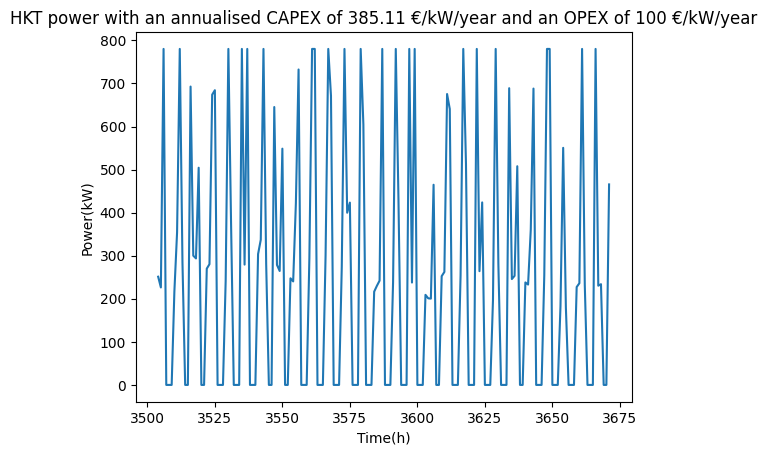

HKT capacity: 780.16 kW
HKT annual electricity production: 2726351.28 kWh


In [5]:
plt.plot(time[start_time:end_time],HKT_power[0][start_time:end_time])
plt.title(f"HKT power with an annualised CAPEX of {round(HKT_an_capex[0],2)} €/kW/year and an OPEX of {round(HKT_opex[0],2)} €/kW/year")
plt.xlabel("Time(h)")
plt.ylabel("Power(kW)")
plt.show()
print(f'HKT capacity: {round(HKT_capacity[0],2)} kW')
print(f'HKT annual electricity production: {round(sum(HKT_power[0]),2)} kWh')

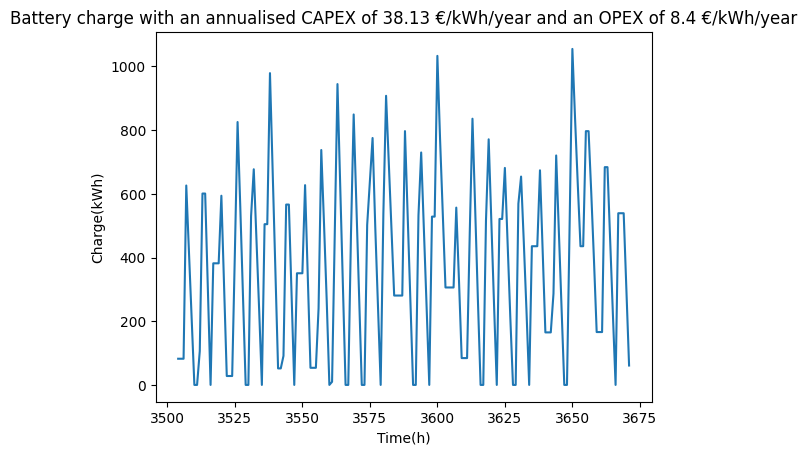

Battery capacity: 1260.65 kWh


In [6]:
plt.plot(time[start_time:end_time],battery_charge[0][start_time:end_time])
plt.title(f"Battery charge with an annualised CAPEX of {round(battery_an_capex[0],2)} €/kWh/year and an OPEX of {round(battery_opex[0],2)} €/kWh/year")
plt.xlabel("Time(h)")
plt.ylabel("Charge(kWh)")
plt.show()
print(f'Battery capacity: {round(battery_capacity[0],2)} kWh')

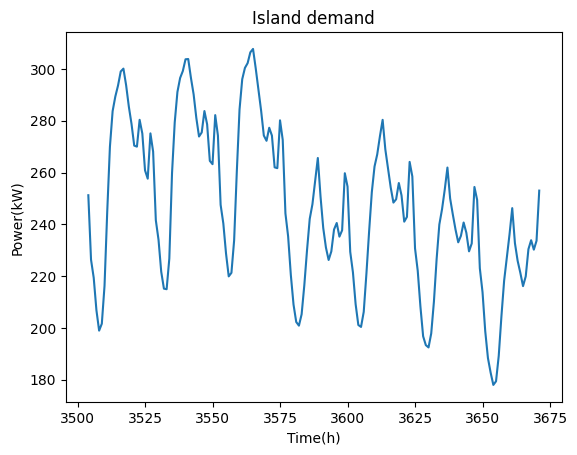

Yearly electricity demand: 2659242.72 kWh


In [7]:
plt.plot(time[start_time:end_time],electrical_load[0][start_time:end_time])
plt.title("Island demand")
plt.xlabel("Time(h)")
plt.ylabel("Power(kW)")
plt.show()
yearly_elec_demand=sum(electrical_load[0])
print(f'Yearly electricity demand: {round(yearly_elec_demand,2)} kWh')

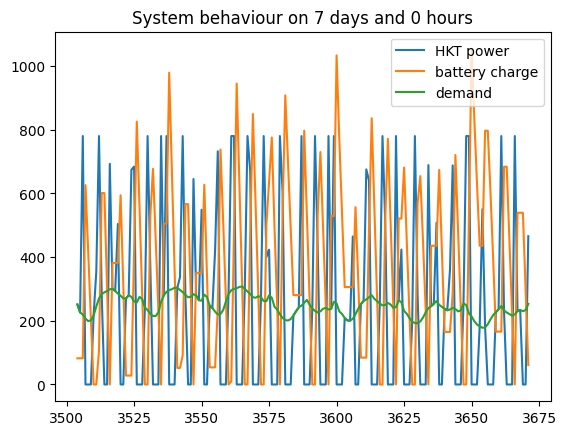

Electricity cost: 0.164 €/kWh


In [8]:
plt.plot(time[start_time:end_time],HKT_power[0][start_time:end_time])
plt.plot(time[start_time:end_time],battery_charge[0][start_time:end_time])
plt.plot(time[start_time:end_time],electrical_load[0][start_time:end_time])
plt.legend(["HKT power","battery charge","demand"])
plt.title(f'System behaviour on {(end_time-start_time)//24} days and {(end_time-start_time)%24} hours')
plt.show()
elec_price=objective/yearly_elec_demand
print(f'Electricity cost: {round(elec_price,3)} €/kWh')